# Day 5 — Machine Learning Completion

Colab practice for Unsupervised Learning, Ensemble Learning, Semi-Supervised Learning, Reinforcement Learning basics, Model Evaluation, and Model Optimization.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.semi_supervised import SelfTrainingClassifier


## Load Iris Dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
X_scaled = StandardScaler().fit_transform(X)
print(X.shape)

(150, 4)


## K-Means Clustering

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
print(clusters[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## Elbow Method

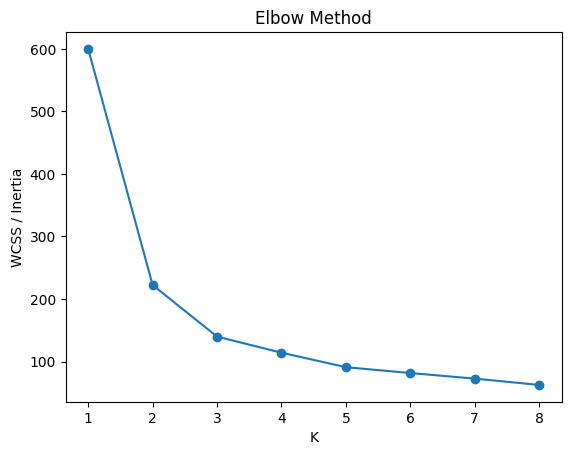

In [4]:
inertias = []
for k in range(1, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(range(1, 9), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.show()

## Hierarchical Clustering

In [5]:
hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(X_scaled)
print(hier_labels[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## Dendrogram

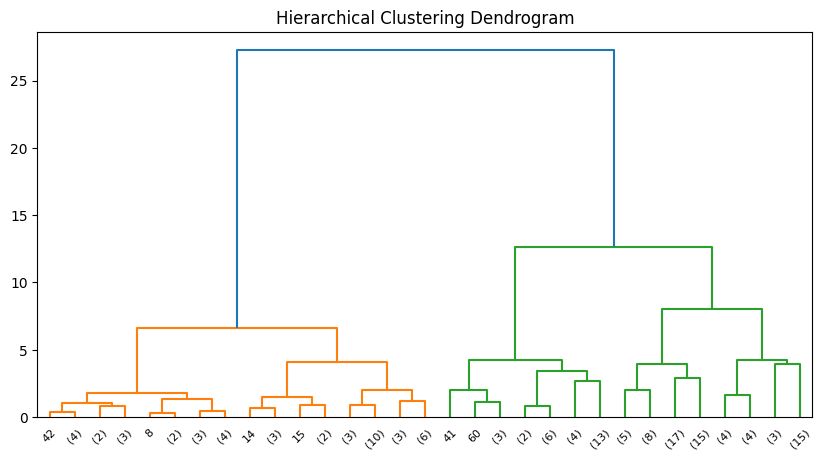

In [6]:
linked = linkage(X_scaled, method="ward")
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode="level", p=4)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

## DBSCAN

In [7]:
db = DBSCAN(eps=0.8, min_samples=5)
db_labels = db.fit_predict(X_scaled)
print("Labels:", np.unique(db_labels))
print("Noise points:", np.sum(db_labels == -1))

Labels: [-1  0  1]
Noise points: 4


## PCA

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_)

Original shape: (150, 4)
Reduced shape: (150, 2)
Explained variance: [0.72962445 0.22850762]


## Prepare Classification Dataset

In [9]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Bagging

In [10]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bag.fit(X_train, y_train)
pred = bag.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9385964912280702


## Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.956140350877193


## AdaBoost

In [12]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
pred = ada.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.956140350877193


## Gradient Boosting

In [13]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.956140350877193


## XGBoost

In [14]:
!pip -q install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9473684210526315


## Semi-Supervised Learning — Self Training

In [15]:
rng = np.random.RandomState(42)
y_partial = y_train.copy()
mask = rng.rand(len(y_partial)) < 0.6
y_partial[mask] = -1

base_model = LogisticRegression(max_iter=2000)
self_train = SelfTrainingClassifier(base_model, threshold=0.8)
self_train.fit(X_train_scaled, y_partial)

pred = self_train.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9824561403508771


## Reinforcement Learning — Q Table Concept

In [16]:
states = ["Start", "Middle"]
actions = ["left", "right"]

q_table = pd.DataFrame(0.0, index=states, columns=actions)
q_table

,left,right
Start,0.0,0.0
Middle,0.0,0.0


## Q-Learning Update

In [17]:
alpha = 0.1
gamma = 0.9
reward = 10

state = "Middle"
action = "right"

old_q = q_table.loc[state, action]
max_future_q = 0

q_table.loc[state, action] = old_q + alpha * (
    reward + gamma * max_future_q - old_q
)

q_table

,left,right
Start,0.0,0.0
Middle,0.0,1.0


## Logistic Regression for Evaluation

In [18]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)
proba = model.predict_proba(X_test_scaled)[:, 1]

## Confusion Matrix

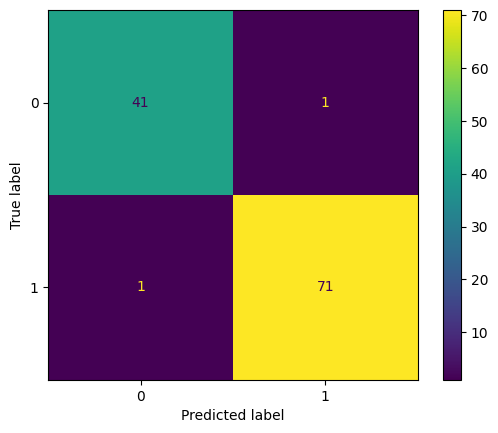

In [19]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Accuracy / Precision / Recall / F1

In [20]:
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1: 0.9861111111111112


## ROC-AUC

ROC-AUC: 0.9953703703703703


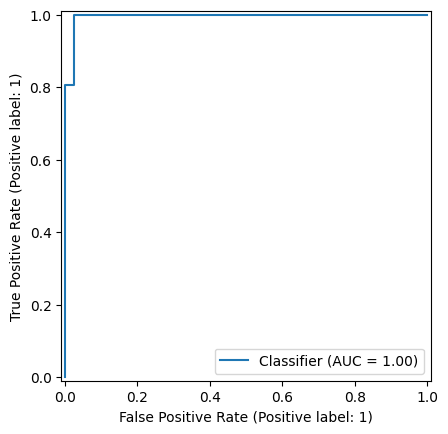

In [21]:
print("ROC-AUC:", roc_auc_score(y_test, proba))
RocCurveDisplay.from_predictions(y_test, proba)
plt.show()

## Precision-Recall Curve

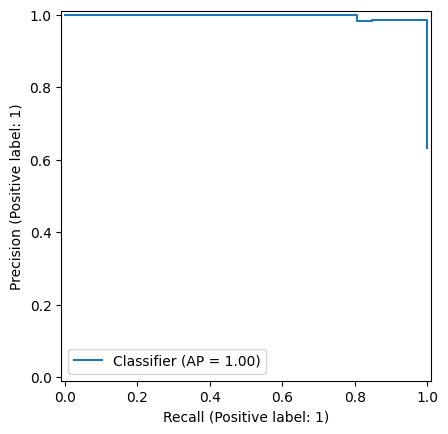

In [22]:
PrecisionRecallDisplay.from_predictions(y_test, proba)
plt.show()

## Cross-Validation

In [23]:
scores = cross_val_score(
    LogisticRegression(max_iter=2000),
    StandardScaler().fit_transform(X),
    y,
    cv=5,
    scoring="accuracy"
)
print(scores)
print("Mean CV Accuracy:", scores.mean())

[0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Mean CV Accuracy: 0.9806862288464524


## Stratified K-Fold

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    LogisticRegression(max_iter=2000),
    StandardScaler().fit_transform(X),
    y,
    cv=skf,
    scoring="accuracy"
)

print(scores)
print("Mean:", scores.mean())

[0.97368421 0.94736842 0.96491228 0.99122807 0.99115044]
Mean: 0.9736686849868033


## Overfitting Example

In [25]:
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
deep_tree.fit(X_train, y_train)

print("Train Accuracy:", accuracy_score(y_train, deep_tree.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, deep_tree.predict(X_test)))

Train Accuracy: 1.0
Test Accuracy: 0.9122807017543859


## Underfitting Example

In [26]:
small_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
small_tree.fit(X_train, y_train)

print("Train Accuracy:", accuracy_score(y_train, small_tree.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, small_tree.predict(X_test)))

Train Accuracy: 0.9230769230769231
Test Accuracy: 0.9210526315789473


## Regularization

In [27]:
for c in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=c, max_iter=2000)
    model.fit(X_train_scaled, y_train)
    print("C =", c, "Accuracy =", accuracy_score(y_test, model.predict(X_test_scaled)))

C = 0.01 Accuracy = 0.9473684210526315
C = 0.1 Accuracy = 0.9736842105263158
C = 1 Accuracy = 0.9824561403508771
C = 10 Accuracy = 0.9649122807017544
C = 100 Accuracy = 0.9473684210526315


## Grid Search

In [28]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best CV Score: 0.9802197802197803


## Random Search

In [29]:
param_dist = {
    "C": np.logspace(-2, 2, 20),
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"]
}

random_search = RandomizedSearchCV(
    SVC(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    scoring="accuracy"
)

random_search.fit(X_train_scaled, y_train)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'kernel': 'linear', 'gamma': 'auto', 'C': np.float64(0.29763514416313175)}
Best CV Score: 0.9736263736263737


## Data Leakage — Correct Scaling Order

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target,
    test_size=0.2,
    random_state=42,
    stratify=cancer.target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Correct: scaler fitted only on training data.")

Correct: scaler fitted only on training data.


## Final Day 5 Summary

In [31]:
summary = pd.DataFrame({
    "Concept": [
        "K-Means", "Hierarchical", "DBSCAN",
        "Bagging", "AdaBoost", "Gradient Boosting", "XGBoost",
        "Semi-Supervised Learning", "Reinforcement Learning",
        "Cross-Validation", "Regularization", "Grid Search", "Random Search"
    ],
    "Memory Point": [
        "Centroid clustering", "Dendrogram hierarchy", "Density + noise",
        "Independent learners", "Reweight mistakes", "Fit residuals", "Optimized boosting",
        "Few labeled + many unlabeled", "Learn from rewards",
        "Evaluate across splits", "Reduce overfitting",
        "Try all specified combinations", "Try random combinations"
    ]
})
summary

,Concept,Memory Point
0,K-Means,Centroid clustering
1,Hierarchical,Dendrogram hierarchy
2,DBSCAN,Density + noise
3,Bagging,Independent learners
4,AdaBoost,Reweight mistakes
5,Gradient Boosting,Fit residuals
6,XGBoost,Optimized boosting
7,Semi-Supervised Learning,Few labeled + many unlabeled
8,Reinforcement Learning,Learn from rewards
9,Cross-Validation,Evaluate across splits
